# 60/40은 아직 유효한가 — 다자산 상관관계 분석

 → 를 사용해 수집·정제·분석·시각화. 위에서부터 순서대로 실행.

In [1]:
# [셀1] 환경 준비 및 모듈 로드
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))
warnings.filterwarnings("ignore")

from src.fetch_data import load
from src import metrics as M

FIG = ROOT / "figures"; FIG.mkdir(exist_ok=True)
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.unicode_minus"] = False
# 한글 폰트: macOS AppleGothic / Windows Malgun Gothic / Linux NanumGothic
mpl.rcParams["font.family"] = "AppleGothic"


In [2]:
# [셀2] 데이터 로드 및 기간·컬럼·결측 확인
prices_raw, macro = load()
print(prices_raw.info())

summary = pd.DataFrame({
    "시작일": prices_raw.apply(lambda s: s.first_valid_index()),
    "종료일": prices_raw.apply(lambda s: s.last_valid_index()),
    "관측수": prices_raw.notna().sum(),
    "결측수": prices_raw.isna().sum(),
})
summary   # → 리포트 §3 데이터 설명 표에 그대로 붙여넣기


<class 'pandas.DataFrame'>
DatetimeIndex: 6863 entries, 2004-11-18 to 2026-09-23
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   SPY      5493 non-null   float64
 1   SHY      5493 non-null   float64
 2   TLT      5493 non-null   float64
 3   GLD      5493 non-null   float64
 4   BTC-USD  4389 non-null   float64
 5   IBIT     675 non-null    float64
dtypes: float64(6)
memory usage: 375.3 KB
None


,시작일,종료일,관측수,결측수
SPY,2004-11-18,2026-09-21,5493,1370
SHY,2004-11-18,2026-09-21,5493,1370
TLT,2004-11-18,2026-09-21,5493,1370
GLD,2004-11-18,2026-09-21,5493,1370
BTC-USD,2014-09-17,2026-09-23,4389,2474
IBIT,2024-01-11,2026-09-21,675,6188


In [3]:
# [셀3] 거래일 정렬 + 창 A/B/C 분리
prices = M.align_to_market(prices_raw, "SPY")     # SPY 거래일 기준, BTC 주말 제거

WIN_A = ["SPY", "SHY", "TLT", "GLD"]
WIN_B = WIN_A + ["BTC-USD"]
WIN_C = WIN_A + ["IBIT"]

pA = prices[WIN_A].dropna()
pB = prices[WIN_B].dropna()
pC = prices[WIN_C].dropna()

rA, rB, rC = M.daily_returns(pA), M.daily_returns(pB), M.daily_returns(pC)
print({"A": len(rA), "B": len(rB), "C": len(rC)})   # A는 5,000+ → 요건 충족 근거

# 이상치: ±10% 초과 일간 수익률은 2008·2020의 실제 사건 → 제거하지 않는다(근거를 리포트에 기재)
outliers = (rB.abs() > 0.10).sum()
outliers


{'A': 5492, 'B': 3019, 'C': 674}


SPY          2
SHY          0
TLT          0
GLD          1
BTC-USD    114
dtype: int64

In [4]:
# [셀4] 금리·물가 정렬 (월별 CPI는 ffill, 미래 보간 금지)
dff = macro["DFF"].reindex(prices.index).ffill()
cpi_yoy = M.inflation_yoy(macro["CPIAUCSL"]).reindex(prices.index).ffill()
regime = M.rate_regime(dff)
regime.value_counts()


regime
동결    3888
인상     950
인하     655
Name: count, dtype: int64

In [5]:
# [셀5] 기법 2~6: 롤링 상관 / 변동성 / 낙폭 / 조건부 통계 / 국면 집계
corr_A = M.rolling_corr(rA, "SPY", 252)
corr_B = M.rolling_corr(rB, "SPY", 252)
vol_B  = M.rolling_vol(rB)
cum_B  = M.cumulative(rB)
dd_B   = M.drawdown(cum_B)

crash = M.crash_day_stats(rB, "SPY", 0.05)        # Q3
regime_corr = corr_B.join(regime).groupby("regime").mean()   # Q2 해석
annual = (rB.groupby(rB.index.year).apply(lambda d: (1 + d).prod() - 1))  # Q1 히트맵용

display(crash.round(4)); display(regime_corr.round(3)); display(annual.round(3).tail(6))


,전체 평균,급락일 평균(하위 5%),급락일 승률
SPY,0.0006,-0.0264,0.0000
SHY,0.0001,0.0004,0.6291
TLT,0.0000,0.0049,0.6887
GLD,0.0005,0.0011,0.5099
BTC-USD,0.0026,-0.0247,0.2980


,SHY,TLT,GLD,BTC-USD
regime,,,,
동결,-0.145,-0.160,0.028,0.198
인상,-0.056,-0.117,0.005,0.294
인하,-0.218,-0.204,0.008,0.183


,SPY,SHY,TLT,GLD,BTC-USD
date,,,,,
2021,0.287,-0.007,-0.046,-0.041,0.597
2022,-0.182,-0.039,-0.312,-0.008,-0.641
2023,0.262,0.042,0.028,0.127,1.536
2024,0.249,0.039,-0.081,0.267,1.219
2025,0.177,0.050,0.042,0.637,-0.063
2026,0.143,0.005,-0.033,0.005,-0.010


In [6]:
# [셀6] 5개 조합 성과 비교표 (Q5)
PORTS = {
    "클래식 60/40": {"SPY": .6, "TLT": .4},
    "단기채 60/40": {"SPY": .6, "SHY": .4},
    "금 추가":      {"SPY": .55, "TLT": .3, "GLD": .15},
    "5자산":        {"SPY": .5, "SHY": .15, "TLT": .15, "GLD": .15, "BTC-USD": .05},
    "100% 주식":    {"SPY": 1.0},
}
port_ret = pd.DataFrame({k: M.portfolio_returns(rB, w) for k, w in PORTS.items()})
table = pd.DataFrame({k: M.summarize(port_ret[k]) for k in port_ret}).T
table["2022년"] = port_ret.loc["2022"].add(1).prod() - 1
table.round(4)   # → 리포트 표로 복사


,CAGR,Vol,MaxDD,Sharpe,2022년
클래식 60/40,0.0893,0.1109,-0.2724,0.8056,-0.2283
단기채 60/40,0.0915,0.1046,-0.2062,0.8746,-0.1214
금 추가,0.0996,0.1056,-0.2428,0.9431,-0.1915
5자산,0.1285,0.1058,-0.2277,1.2155,-0.1789
100% 주식,0.1384,0.1747,-0.3372,0.7922,-0.1818


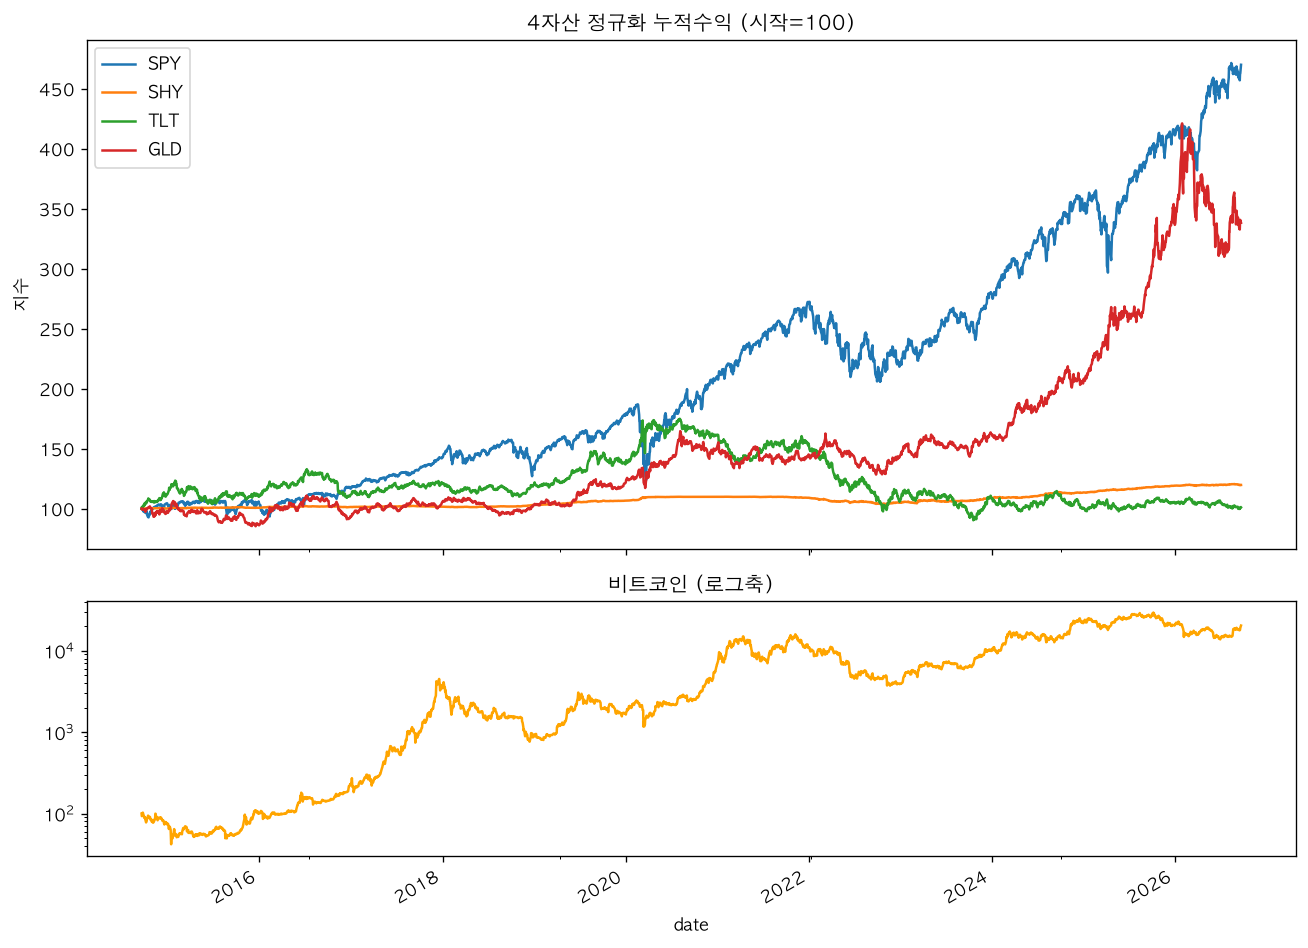

In [7]:
# [셀7] F1 정규화 누적수익 (BTC는 로그축 별도)
fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})
(cum_B[WIN_A] / cum_B[WIN_A].iloc[0] * 100).plot(ax=ax[0])
ax[0].set_title("4자산 정규화 누적수익 (시작=100)"); ax[0].set_ylabel("지수")
(cum_B["BTC-USD"] / cum_B["BTC-USD"].iloc[0] * 100).plot(ax=ax[1], color="orange", logy=True)
ax[1].set_title("비트코인 (로그축)")
fig.tight_layout(); fig.savefig(FIG / "F1_cumulative.png"); plt.show()


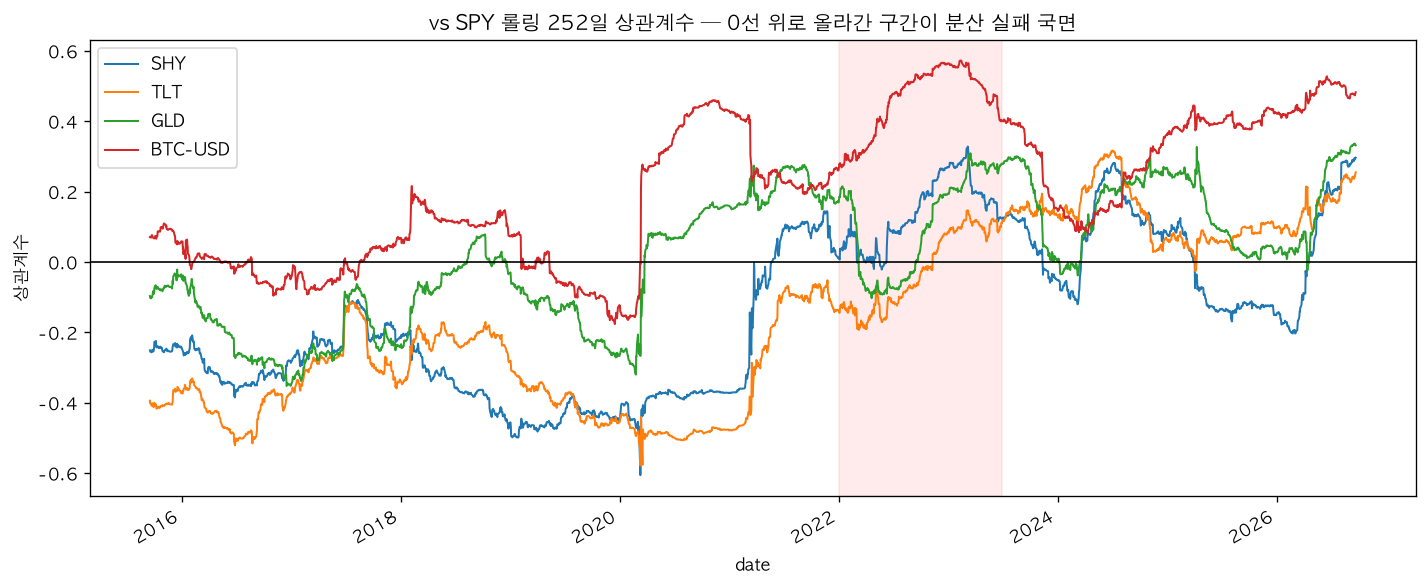

In [8]:
# [셀8] F2 ⭐대표 이미지: 롤링 252일 상관계수
fig, ax = plt.subplots(figsize=(12, 5))
corr_B.plot(ax=ax, lw=1.2)
ax.axhline(0, color="black", lw=1)
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2023-06-30"), color="red", alpha=.08)
ax.set_title("vs SPY 롤링 252일 상관계수 — 0선 위로 올라간 구간이 분산 실패 국면")
ax.set_ylabel("상관계수")
fig.tight_layout(); fig.savefig(FIG / "F2_rolling_corr.png"); plt.show()


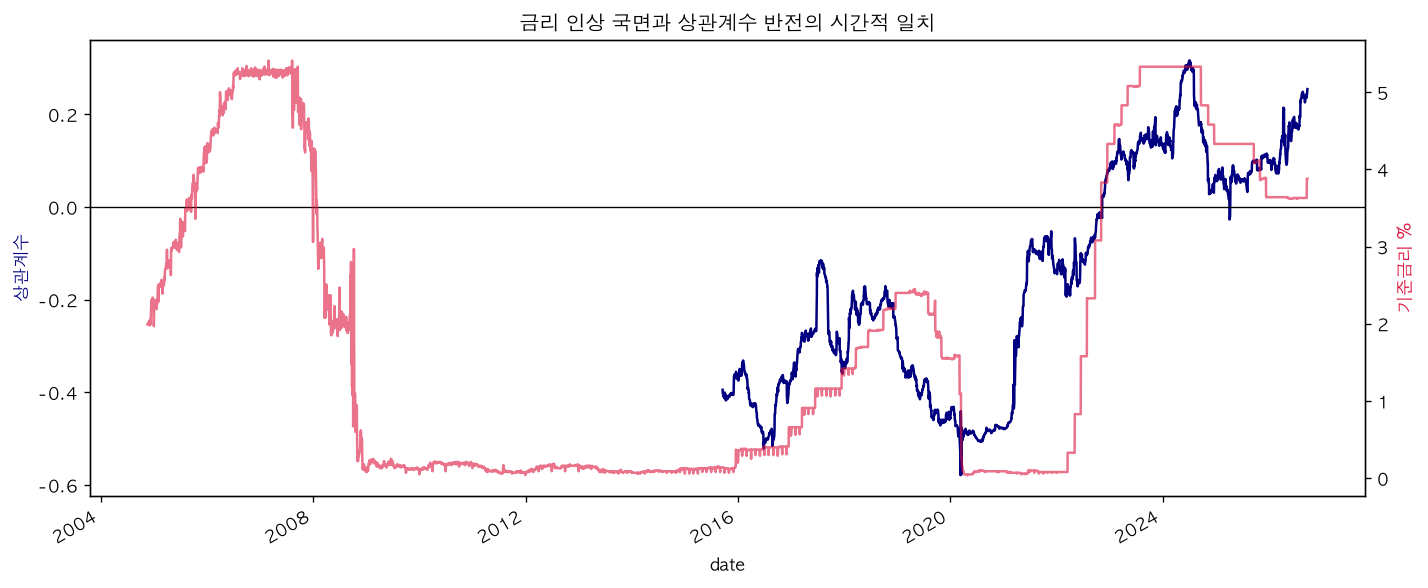

In [9]:
# [셀9] F3 상관계수 + 기준금리 이중축
fig, ax1 = plt.subplots(figsize=(12, 5))
corr_B["TLT"].plot(ax=ax1, color="navy", label="TLT-SPY 상관")
ax1.axhline(0, color="black", lw=.8); ax1.set_ylabel("상관계수", color="navy")
ax2 = ax1.twinx()
dff.plot(ax=ax2, color="crimson", alpha=.6, label="기준금리(DFF)")
ax2.set_ylabel("기준금리 %", color="crimson")
ax1.set_title("금리 인상 국면과 상관계수 반전의 시간적 일치")
fig.tight_layout(); fig.savefig(FIG / "F3_corr_rate.png"); plt.show()


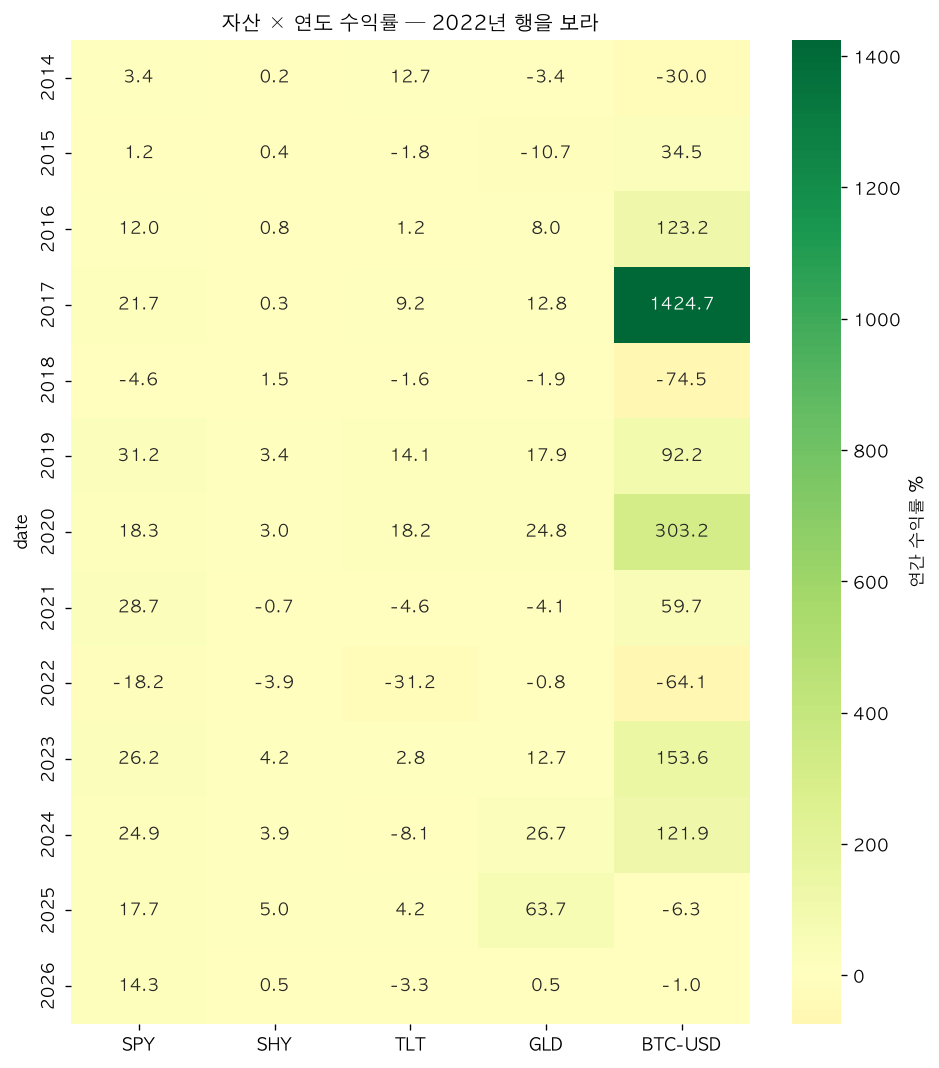

In [10]:
# [셀10] F4 연도×자산 수익률 히트맵
import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(annual * 100, annot=True, fmt=".1f", center=0,
            cmap="RdYlGn", cbar_kws={"label": "연간 수익률 %"}, ax=ax)
ax.set_title("자산 × 연도 수익률 — 2022년 행을 보라")
fig.tight_layout(); fig.savefig(FIG / "F4_heatmap.png"); plt.show()


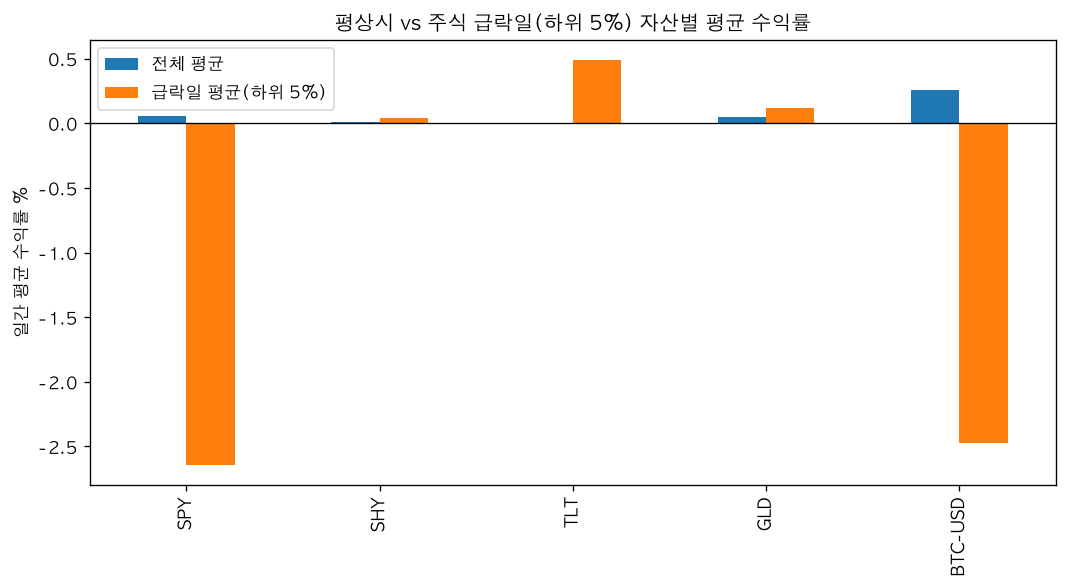

In [11]:
# [셀11] F5 주식 급락일 조건부 평균 수익률
fig, ax = plt.subplots(figsize=(9, 5))
crash[["전체 평균", crash.columns[1]]].mul(100).plot.bar(ax=ax)
ax.axhline(0, color="black", lw=.8); ax.set_ylabel("일간 평균 수익률 %")
ax.set_title("평상시 vs 주식 급락일(하위 5%) 자산별 평균 수익률")
fig.tight_layout(); fig.savefig(FIG / "F5_crash_days.png"); plt.show()


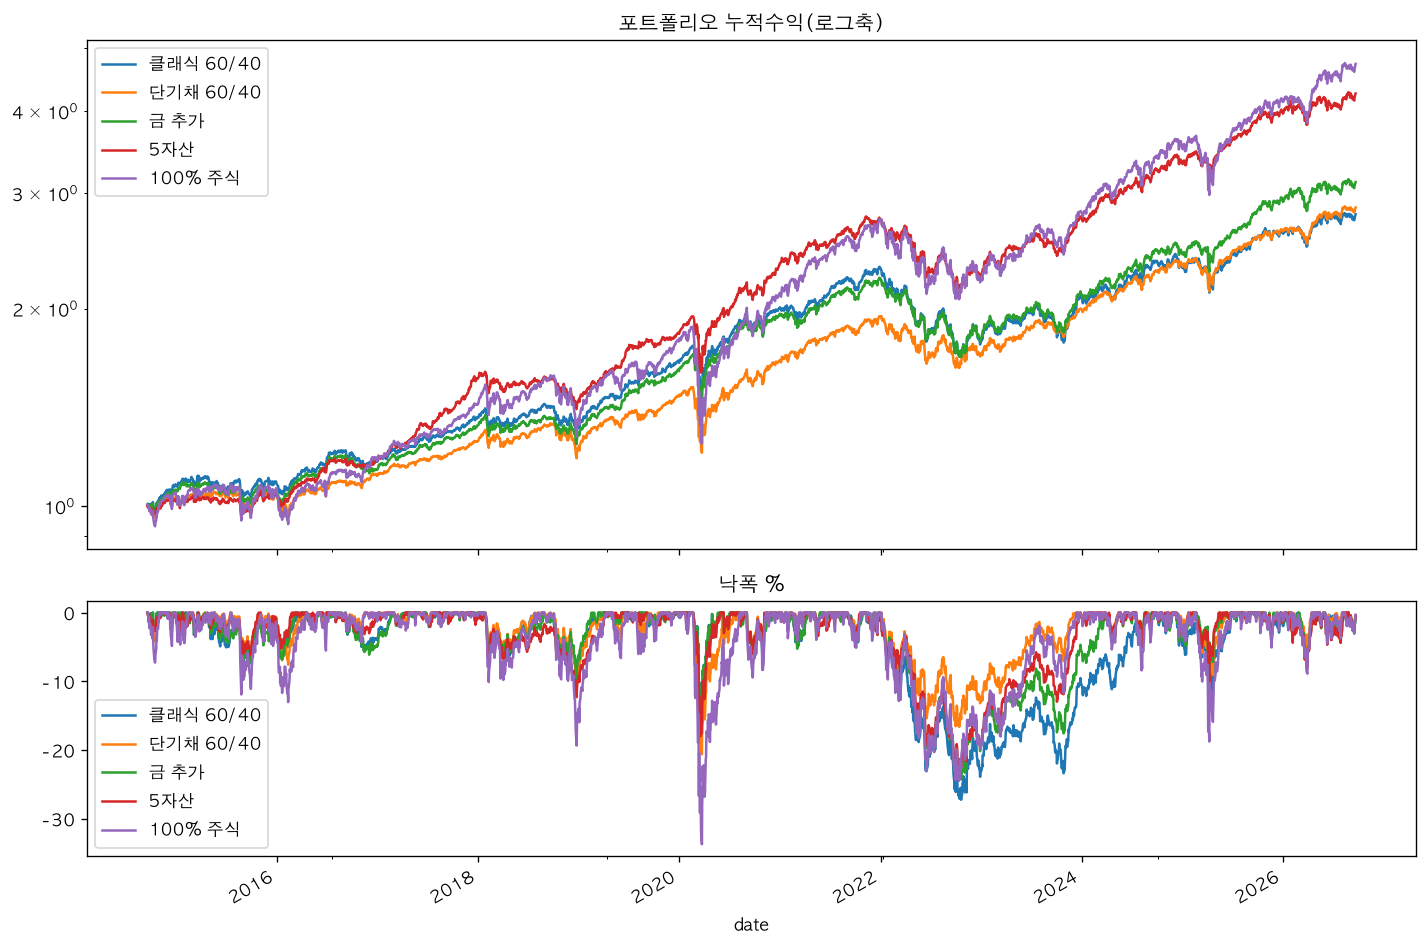

In [12]:
# [셀12] F6 포트폴리오 누적수익 + 낙폭
cum_p = M.cumulative(port_ret)
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})
cum_p.plot(ax=ax[0], logy=True); ax[0].set_title("포트폴리오 누적수익(로그축)")
M.drawdown(cum_p).mul(100).plot(ax=ax[1]); ax[1].set_title("낙폭 %")
fig.tight_layout(); fig.savefig(FIG / "F6_portfolios.png"); plt.show()


In [13]:
# [셀13] BTC-USD 현물 결과가 IBIT ETF로도 재현되는지 확인
print(rC.corr()["SPY"])
print(rB.loc[rC.index].corr()["SPY"])   # 같은 기간 현물 기준 — 두 값이 유사하면 대체가 정당화됨


SPY     1.000000
SHY     0.044108
TLT     0.125342
GLD     0.184425
IBIT    0.405863
Name: SPY, dtype: float64
SPY        1.000000
SHY        0.044108
TLT        0.125342
GLD        0.184425
BTC-USD    0.382369
Name: SPY, dtype: float64
